# Workshop 3 — ETL Streaming with Apache Kafka
## Step 1 & 2: Exploratory Data Analysis (EDA) + Data Cleaning & Harmonization

**Course:** ETL (G01) — Data Engineering and Artificial Intelligence  
**Dataset:** World Happiness Report 2015–2019

In [1]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 1. Data Loading

In [2]:
# Paths 
DATA_PATH = '../data/raw/'

files = {
    2015: pd.read_csv(DATA_PATH + '2015.csv'),
    2016: pd.read_csv(DATA_PATH + '2016.csv'),
    2017: pd.read_csv(DATA_PATH + '2017.csv'),
    2018: pd.read_csv(DATA_PATH + '2018.csv'),
    2019: pd.read_csv(DATA_PATH + '2019.csv'),
}

for year, df in files.items():
    print(f'\n=== {year} ===')
    print(f'Shape: {df.shape}')
    print(f'Columns: {list(df.columns)}')


=== 2015 ===
Shape: (158, 12)
Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

=== 2016 ===
Shape: (157, 13)
Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

=== 2017 ===
Shape: (155, 12)
Columns: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

=== 2018 ===
Shape: (156, 9)
Columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life 

---
## 2. Schema Differences Between Years

The datasets **do not share the same schema**. Here we analyze which columns each year has.

In [3]:
print('Columns per year:')
for year, df in files.items():
    print(f'\n{year}:')
    for col in df.columns:
        print(f'  - {col} ({df[col].dtype})')

Columns per year:

2015:
  - Country (str)
  - Region (str)
  - Happiness Rank (int64)
  - Happiness Score (float64)
  - Standard Error (float64)
  - Economy (GDP per Capita) (float64)
  - Family (float64)
  - Health (Life Expectancy) (float64)
  - Freedom (float64)
  - Trust (Government Corruption) (float64)
  - Generosity (float64)
  - Dystopia Residual (float64)

2016:
  - Country (str)
  - Region (str)
  - Happiness Rank (int64)
  - Happiness Score (float64)
  - Lower Confidence Interval (float64)
  - Upper Confidence Interval (float64)
  - Economy (GDP per Capita) (float64)
  - Family (float64)
  - Health (Life Expectancy) (float64)
  - Freedom (float64)
  - Trust (Government Corruption) (float64)
  - Generosity (float64)
  - Dystopia Residual (float64)

2017:
  - Country (str)
  - Happiness.Rank (int64)
  - Happiness.Score (float64)
  - Whisker.high (float64)
  - Whisker.low (float64)
  - Economy..GDP.per.Capita. (float64)
  - Family (float64)
  - Health..Life.Expectancy. (float6

---
## 3. Data Quality Analysis Per Year

### 3.1 Missing Values

In [4]:
print('Missing values per column and year:')
for year, df in files.items():
    nulls = df.isnull().sum()
    if nulls.any():
        print(f'\n{year}:')
        print(nulls[nulls > 0])
    else:
        print(f'\n{year}: No missing values ✓')

Missing values per column and year:

2015: No missing values ✓

2016: No missing values ✓

2017: No missing values ✓

2018:
Perceptions of corruption    1
dtype: int64

2019: No missing values ✓


### 3.2 Duplicated Records

In [5]:
for year, df in files.items():
    dups = df.duplicated().sum()
    print(f'{year}: {dups} duplicates')

2015: 0 duplicates
2016: 0 duplicates
2017: 0 duplicates
2018: 0 duplicates
2019: 0 duplicates


### 3.3 Descriptive Statistics

In [6]:
for year, df in files.items():
    print(f'\n=== {year} ===')
    display(df.describe())


=== 2015 ===


,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140



=== 2016 ===


,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,78.980892,5.382185,5.282395,5.481975,0.953880,0.793621,0.557619,0.370994,0.137624,0.242635,2.325807
std,45.466030,1.141674,1.148043,1.136493,0.412595,0.266706,0.229349,0.145507,0.111038,0.133756,0.542220
min,1.000000,2.905000,2.732000,3.078000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.817890
25%,40.000000,4.404000,4.327000,4.465000,0.670240,0.641840,0.382910,0.257480,0.061260,0.154570,2.031710
50%,79.000000,5.314000,5.237000,5.419000,1.027800,0.841420,0.596590,0.397470,0.105470,0.222450,2.290740
75%,118.000000,6.269000,6.154000,6.434000,1.279640,1.021520,0.729930,0.484530,0.175540,0.311850,2.664650
max,157.000000,7.526000,7.460000,7.669000,1.824270,1.183260,0.952770,0.608480,0.505210,0.819710,3.837720



=== 2017 ===


,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485



=== 2018 ===


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000
mean,78.500000,5.375917,0.891449,1.213237,0.597346,0.454506,0.181006,0.112000
std,45.177428,1.119506,0.391921,0.302372,0.247579,0.162424,0.098471,0.096492
min,1.000000,2.905000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.453750,0.616250,1.066750,0.422250,0.356000,0.109500,0.051000
50%,78.500000,5.378000,0.949500,1.255000,0.644000,0.487000,0.174000,0.082000
75%,117.250000,6.168500,1.197750,1.463000,0.777250,0.578500,0.239000,0.137000
max,156.000000,7.632000,2.096000,1.644000,1.030000,0.724000,0.598000,0.457000



=== 2019 ===


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


---
## 4. Schema Harmonization

**Design decision:** Each year uses different column names for the same concepts.
We create a unified mapping based on the semantic meaning of each column.

**Proposed unified schema:**

| Unified field | Description |
|---|---|
| `country` | Country |
| `year` | Report year |
| `happiness_score` | Happiness score (target) |
| `gdp` | GDP per capita |
| `family` | Social / family support |
| `health` | Healthy life expectancy |
| `freedom` | Freedom to make life choices |
| `generosity` | Generosity |
| `corruption` | Perception of corruption |

In [7]:
# Mapping from original column names → unified schema per year
column_maps = {
    2015: {
        'Country': 'country',
        'Happiness Score': 'happiness_score',
        'Economy (GDP per Capita)': 'gdp',
        'Family': 'family',
        'Health (Life Expectancy)': 'health',
        'Freedom': 'freedom',
        'Trust (Government Corruption)': 'corruption',
        'Generosity': 'generosity',
    },
    2016: {
        'Country': 'country',
        'Happiness Score': 'happiness_score',
        'Economy (GDP per Capita)': 'gdp',
        'Family': 'family',
        'Health (Life Expectancy)': 'health',
        'Freedom': 'freedom',
        'Trust (Government Corruption)': 'corruption',
        'Generosity': 'generosity',
    },
    2017: {
        'Country': 'country',
        'Happiness.Score': 'happiness_score',
        'Economy..GDP.per.Capita.': 'gdp',
        'Family': 'family',
        'Health..Life.Expectancy.': 'health',
        'Freedom': 'freedom',
        'Trust..Government.Corruption.': 'corruption',
        'Generosity': 'generosity',
    },
    2018: {
        'Country or region': 'country',
        'Score': 'happiness_score',
        'GDP per capita': 'gdp',
        'Social support': 'family',
        'Healthy life expectancy': 'health',
        'Freedom to make life choices': 'freedom',
        'Perceptions of corruption': 'corruption',
        'Generosity': 'generosity',
    },
    2019: {
        'Country or region': 'country',
        'Score': 'happiness_score',
        'GDP per capita': 'gdp',
        'Social support': 'family',
        'Healthy life expectancy': 'health',
        'Freedom to make life choices': 'freedom',
        'Perceptions of corruption': 'corruption',
        'Generosity': 'generosity',
    },
}

UNIFIED_COLS = ['country', 'year', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']

harmonized_dfs = []

for year, df in files.items():
    mapping = column_maps[year]
    df_renamed = df.rename(columns=mapping)
    df_renamed['year'] = year
    # Select only columns from the unified schema
    available = [c for c in UNIFIED_COLS if c in df_renamed.columns]
    df_clean = df_renamed[available].copy()
    harmonized_dfs.append(df_clean)
    print(f'{year}: {df_clean.shape[0]} rows, available columns: {available}')

df_unified = pd.concat(harmonized_dfs, ignore_index=True)
print(f'\nUnified dataset: {df_unified.shape}')

2015: 158 rows, available columns: ['country', 'year', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
2016: 157 rows, available columns: ['country', 'year', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
2017: 155 rows, available columns: ['country', 'year', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
2018: 156 rows, available columns: ['country', 'year', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
2019: 156 rows, available columns: ['country', 'year', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']

Unified dataset: (782, 9)


---
## 5. Cleaning the Unified Dataset

In [8]:
print('Missing values before cleaning:')
print(df_unified.isnull().sum())

# Strategy: impute numeric nulls with the median per year
numeric_cols = ['gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']

for col in numeric_cols:
    if col in df_unified.columns:
        df_unified[col] = df_unified.groupby('year')[col].transform(
            lambda x: x.fillna(x.median())
        )

# Drop rows where the target or country identifier is missing
df_unified.dropna(subset=['happiness_score', 'country'], inplace=True)

# Normalize country name
df_unified['country'] = df_unified['country'].str.strip()

print('\nMissing values after cleaning:')
print(df_unified.isnull().sum())
print(f'\nFinal shape: {df_unified.shape}')

Missing values before cleaning:
country            0
year               0
happiness_score    0
gdp                0
family             0
health             0
freedom            0
generosity         0
corruption         1
dtype: int64

Missing values after cleaning:
country            0
year               0
happiness_score    0
gdp                0
family             0
health             0
freedom            0
generosity         0
corruption         0
dtype: int64

Final shape: (782, 9)


---
## 6. EDA Visualizations

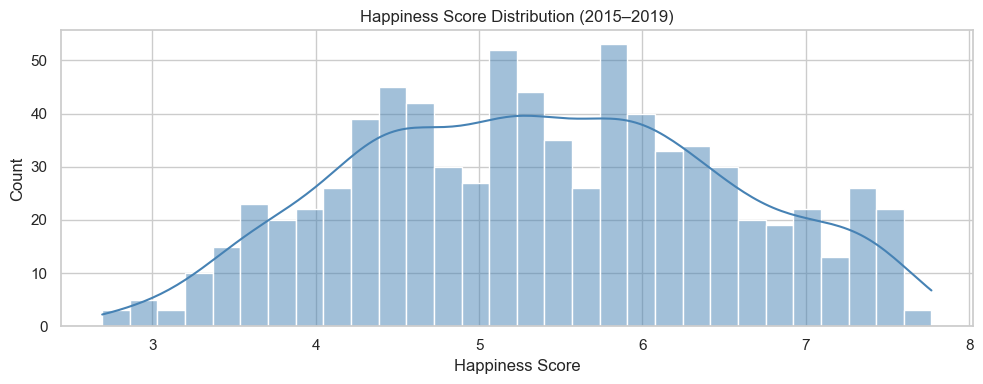

In [9]:
# Happiness score distribution
plt.figure(figsize=(10, 4))
sns.histplot(df_unified['happiness_score'], bins=30, kde=True, color='steelblue')
plt.title('Happiness Score Distribution (2015–2019)')
plt.xlabel('Happiness Score')
plt.tight_layout()
plt.show()

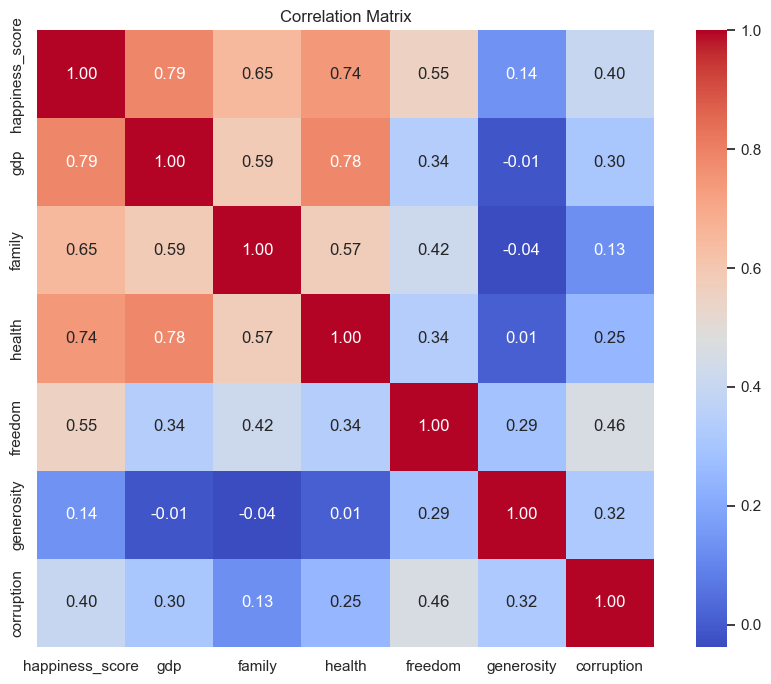

In [10]:
# Correlation matrix
corr_cols = ['happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
corr_df = df_unified[corr_cols].dropna()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

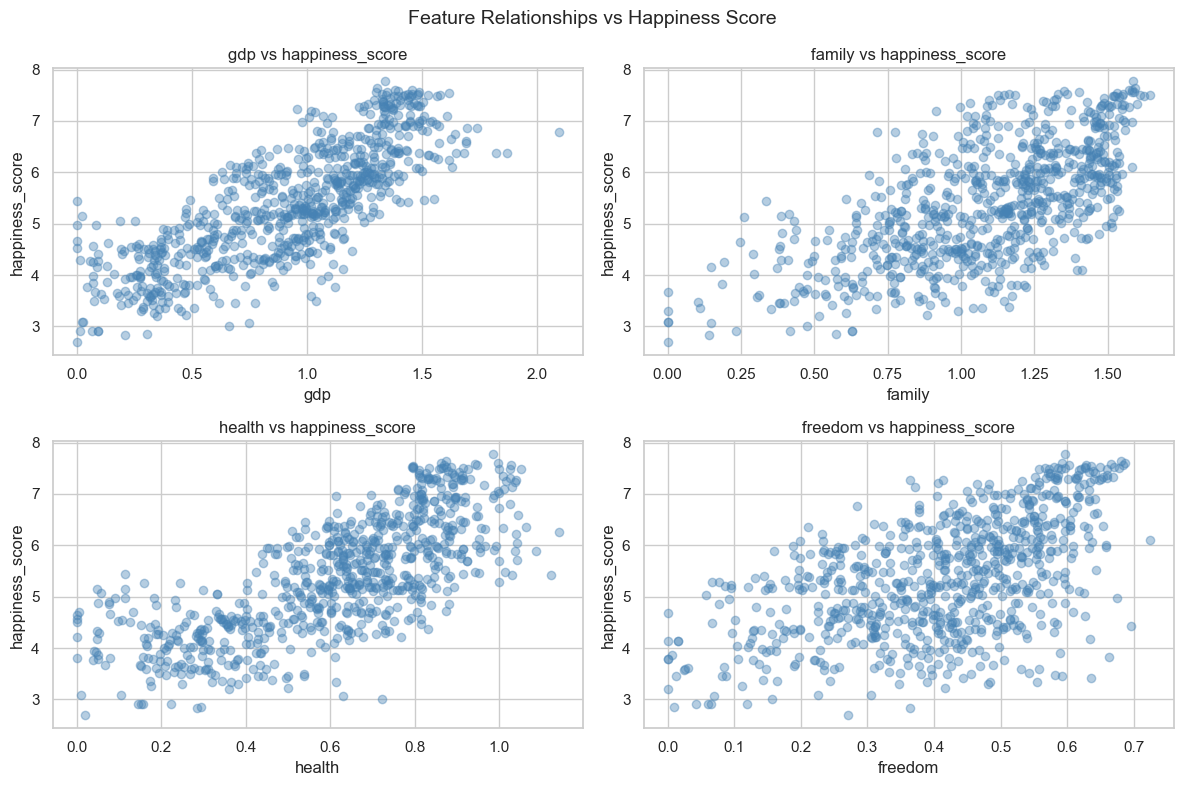

In [11]:
# Scatter plots: features vs happiness score
features = ['gdp', 'family', 'health', 'freedom']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df_unified[feat], df_unified['happiness_score'], alpha=0.4, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('happiness_score')
    ax.set_title(f'{feat} vs happiness_score')

plt.suptitle('Feature Relationships vs Happiness Score', fontsize=14)
plt.tight_layout()
plt.show()

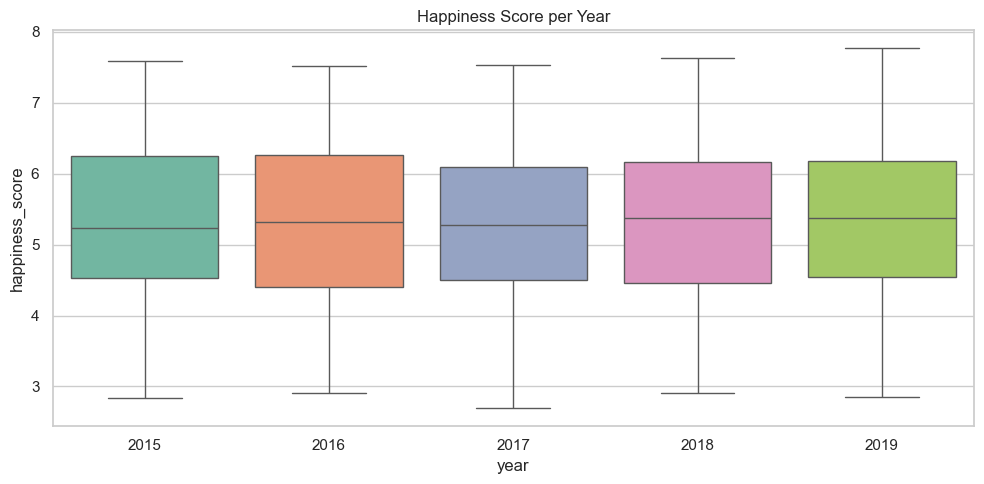

In [12]:
# Boxplot: happiness score per year
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_unified, x='year', y='happiness_score', palette='Set2')
plt.title('Happiness Score per Year')
plt.tight_layout()
plt.show()

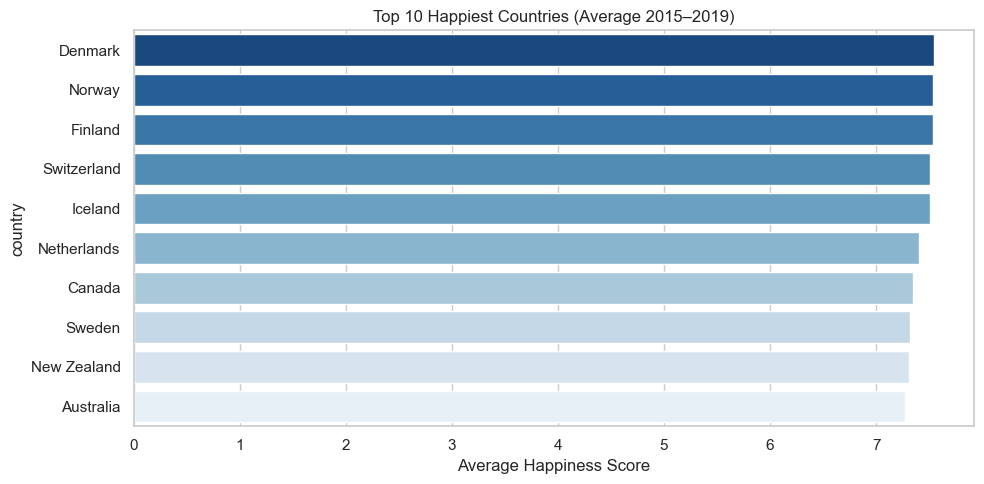

In [13]:
# Top 10 happiest countries (average 2015–2019)
top10 = df_unified.groupby('country')['happiness_score'].mean().nlargest(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='happiness_score', y='country', palette='Blues_r')
plt.title('Top 10 Happiest Countries (Average 2015–2019)')
plt.xlabel('Average Happiness Score')
plt.tight_layout()
plt.show()

---
## 7. Outlier Detection

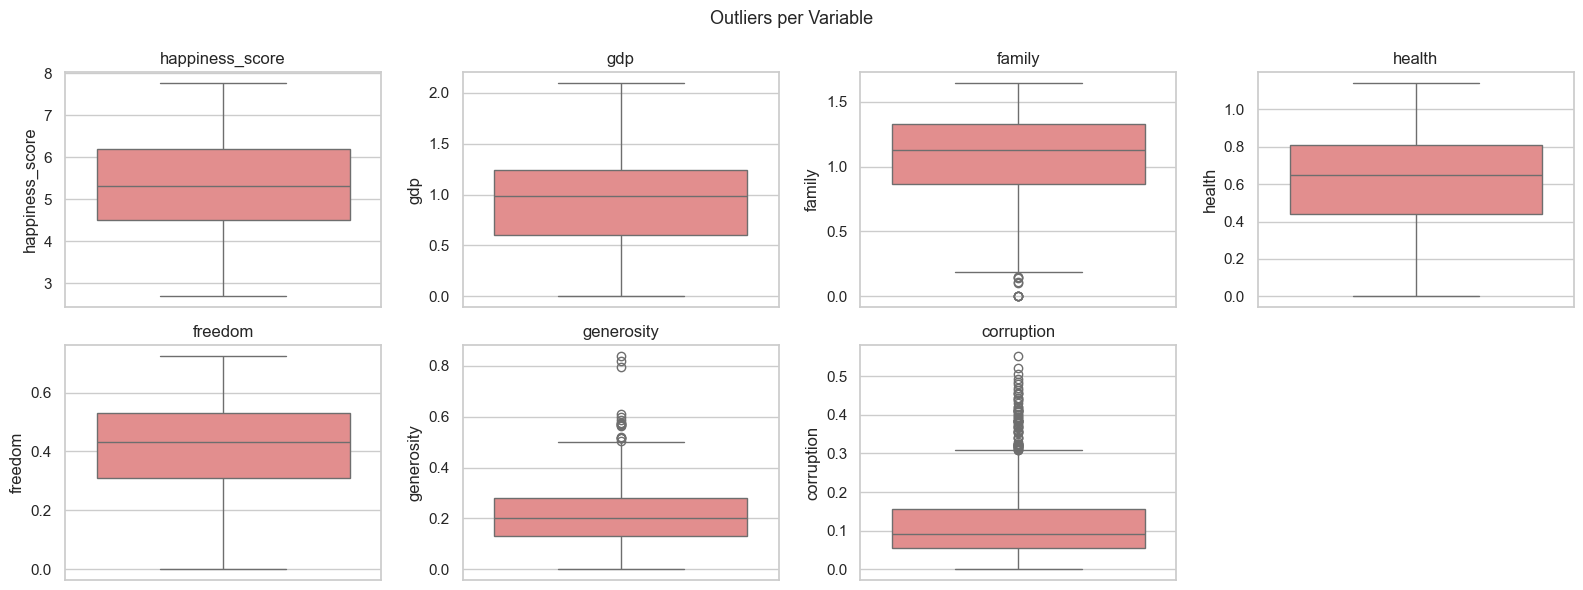

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
cols_to_check = ['happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']

for ax, col in zip(axes.flatten(), cols_to_check):
    if col in df_unified.columns:
        sns.boxplot(y=df_unified[col], ax=ax, color='lightcoral')
        ax.set_title(col)

axes.flatten()[-1].set_visible(False)
plt.suptitle('Outliers per Variable', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Outlier report using IQR method
print('\nOutlier count per variable (IQR method):')
for col in cols_to_check:
    if col in df_unified.columns:
        Q1 = df_unified[col].quantile(0.25)
        Q3 = df_unified[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((df_unified[col] < Q1 - 1.5*IQR) | (df_unified[col] > Q3 + 1.5*IQR)).sum()
        print(f'  {col}: {outliers} outliers')


Outlier count per variable (IQR method):
  happiness_score: 0 outliers
  gdp: 0 outliers
  family: 10 outliers
  health: 0 outliers
  freedom: 0 outliers
  generosity: 17 outliers
  corruption: 68 outliers


---
## 8. Data Quality Observations

| Problem | Affected Year(s) | Decision |
|---|---|---|
| Different column names for the same concept | All years | Unified mapping per year |
| Extra columns (rank, region, etc.) | 2015, 2016, 2017 | Dropped — not relevant for modeling |
| Null values in `corruption` | 2018 | Imputed with median per year |
| Inconsistent data types | Some years | Implicitly cast to float64 by pandas |
| Mild outliers | Generosity, Corruption | Kept — real values from the official report |

---
## 9. Export Unified Dataset

In [16]:
output_path = '../data/processed/happiness_unified.csv'
df_unified.to_csv(output_path, index=False)
print(f'Unified dataset saved to: {output_path}')
print(f'Shape: {df_unified.shape}')
display(df_unified.head(10))

Unified dataset saved to: ../data/processed/happiness_unified.csv
Shape: (782, 9)


,country,year,happiness_score,gdp,family,health,freedom,generosity,corruption
0,Switzerland,2015,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,2015,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,2015,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,2015,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,2015,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957
5,Finland,2015,7.406,1.29025,1.31826,0.88911,0.64169,0.23351,0.41372
6,Netherlands,2015,7.378,1.32944,1.28017,0.89284,0.61576,0.47610,0.31814
7,Sweden,2015,7.364,1.33171,1.28907,0.91087,0.65980,0.36262,0.43844
8,New Zealand,2015,7.286,1.25018,1.31967,0.90837,0.63938,0.47501,0.42922
9,Australia,2015,7.284,1.33358,1.30923,0.93156,0.65124,0.43562,0.35637
